In [1]:
import os
import sys
# set gpu to be pci bus id
os.environ['CUDA_DEVICE_ORDER'] = 'PCI_BUS_ID'
os.environ['CUDA_VISIBLE_DEVICES'] = '2'
# os.environ["JAX_PLATFORM_NAME"] = "cpu"
# set gpu memory usage and turnoff pre-allocated memory TODO: what does the following do??
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] ='false'
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR']='platform'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [2]:
import jax
from jax import random
from jax import lax

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import equinox as eqx
from typing import Tuple, Optional

In [3]:
sys.path.append('/home/jmathew_waller/workspace/e2e-imaging/')
from psf_modules import RMLPSFLayer
from lensless_data_generator import LenslessDataGenerator
from optimizers import E2EOptimizer
from sensor_modules import SensorModule

2026-03-02 11:31:58.140617: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772479918.157654 1868058 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772479918.163318 1868058 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
def wiener_deconv(y: jnp.ndarray, psf: jnp.ndarray, K: float) -> jnp.ndarray:
    """
    y:   (B, H, W) — observed blurred image
    psf: (K, L)    — point spread function (same one used in forward model)
    K:   scalar    — noise-to-signal ratio (regularization). larger = more smoothing.
    
    returns: (B, H, W) estimate of original image
    """
    H, W = y.shape[1], y.shape[2]
    psf_h, psf_w = psf.shape

    if psf_h > H or psf_w > W:
        raise ValueError(f"PSF ({psf_h}x{psf_w}) is larger than image ({H}x{W})")
    
    # Embed PSF in the output image domain and shift so the PSF center is at (0,0)
    pad_h = (psf_h - 1) // 2
    pad_w = (psf_w - 1) // 2

    psf_padded = jnp.zeros((H, W))
    psf_padded = psf_padded.at[:psf_h, :psf_w].set(psf)
    # roll so that the center pixel of the PSF lands at (0,0)
    psf_padded = jnp.roll(psf_padded, (-pad_h, -pad_w), axis=(0, 1))

    # FFTs
    PSF = jnp.fft.rfft2(psf_padded)          # (H, W//2+1)
    Y   = jnp.fft.rfft2(y)                   # (B, H, W//2+1)

    # Wiener filter: H* / (|H|^2 + K)
    PSF_conj  = jnp.conj(PSF)
    PSF_power = jnp.abs(PSF) ** 2
    wiener    = PSF_conj / (PSF_power + K)

    X_est = wiener[None, :, :] * Y           # broadcast over batch

    return jnp.fft.irfft2(X_est, s=(H, W))  # (B, H, W)

In [5]:
def gaussian_noise(image: jnp.ndarray, sigma: float, photon_count: int, key: jax.random.PRNGKey) -> jnp.ndarray:
    image = image * photon_count
    noise = random.normal(key, shape=image.shape) * sigma
    image = jnp.clip(image + noise, 0.0, None)
    return image / photon_count

In [ ]:
class E2E(eqx.Module):
    psf_module: eqx.Module
    sensor_module: eqx.Module
    log_K: jnp.ndarray  # learn in log space to keep K positive

    def __init__(self, 
                 psf_module,
                 sensor_module,
                 log_K=jnp.array(-1.0)):
        
        self.psf_module = psf_module
        self.sensor_module = sensor_module
        self.log_K = log_K # initializes K to ~1e-4
        

    def __call__(self, x: jnp.ndarray, key: Optional[jax.random.PRNGKey] = None, ensure_positive=True) -> tuple:
        # x: (B, H, W)
        key = jax.random.PRNGKey(0) if key is None else key # TODO: ask claude, is this bad seeding?

        K = jnp.exp(self.log_K)  # ensure K is always positive
        psf, y = self.psf_module(x)  # psf:(K, L), y:(B, H, W)
        noisy_y = self.sensor_module(y, key=key, ensure_positive=ensure_positive)
        x_hat = wiener_deconv(noisy_y, psf, K)     # (B, H, W)
        
        return x_hat, noisy_y, psf

In [ ]:
# some constants
photon_count = 160
subset_fraction = 1
seed_value = 42 #TODO: FIX SEEDING
psf_size = (32, 32)
key = jax.random.PRNGKey(seed_value)
learning_rate = 1e-3
dataset_name = 'mnist'
object_size = 32
num_gaussian = 10

noise_enabled = True
gaussian_sigma = 0.5

#other constants
tile_rows=1
tile_cols=1
batch_size=32   

# hyperparameters
log_K = jnp.array(-1.0) #initial starting K value for wiener deconv

#wandb logging stuff
use_wandb = True
project_name = 'e2e_imaging_playground'
run_name = f'mnist_gaussian_sigma_{gaussian_sigma}_photon_count_{photon_count}_num_gaussian_{num_gaussian}'
log_every = 10

In [8]:
# set up wandb config
wandb_config = {
    'general': {
        'seed_value': seed_value,
    },
    
    'dataset': {
        'subset_fraction': subset_fraction,
        'photon_count': photon_count,
        'tile_rows': tile_rows,
        'tile_cols': tile_cols,
        'batch_size': batch_size,
        'dataset_name': dataset_name,
    },
    
    'psf_layer': {
        'object_size': object_size,
        'num_gaussian': num_gaussian,
        'psf_size': psf_size,
        'gaussian_sigma': gaussian_sigma
    },
    
    'optimization': {
        'initial log_K': log_K,
        'learning_rate': learning_rate
    },
    
    'logging': {
        'use_wandb': use_wandb,
        'project_name': project_name,
        'run_name': run_name,
        'log_every': log_every,
    }
}

In [9]:
# the model
key_1, subkey_1 = jax.random.split(key)
key_2, subkey_2 = jax.random.split(key_1)
psf_module = RMLPSFLayer(object_size=32, num_gaussians=10, psf_size=psf_size, key=subkey_1)
sensor_module = SensorModule(photon_count=photon_count, noise_enabled=noise_enabled, gaussian_sigma=gaussian_sigma)
model = E2E(psf_module=psf_module, sensor_module=sensor_module, log_K=log_K)

In [10]:
data_generator = LenslessDataGenerator(photon_count, subset_fraction=subset_fraction, seed=seed_value)
x_train, x_test = data_generator.load_mnist_data()
train_dataset = data_generator.create_dataset(x_train, tile_rows=tile_rows, tile_cols=tile_cols, batch_size=batch_size)

2026-03-02 11:32:04.506564: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1772479924.506765 1868058 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22165 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:5e:00.0, compute capability: 8.6


In [11]:
e2e_optimizer = E2EOptimizer(
    model=model,
    lr=learning_rate,
    use_wandb=False, #TODO: CHANGE
    project_name='e2e_imaging',
    run_name=run_name,
    wandb_config=wandb_config
)

  0%|          | 0/500 [00:00<?, ?it/s]E0302 11:32:07.900077 1868058 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


step 0/500  loss=0.059407  K=0.367512


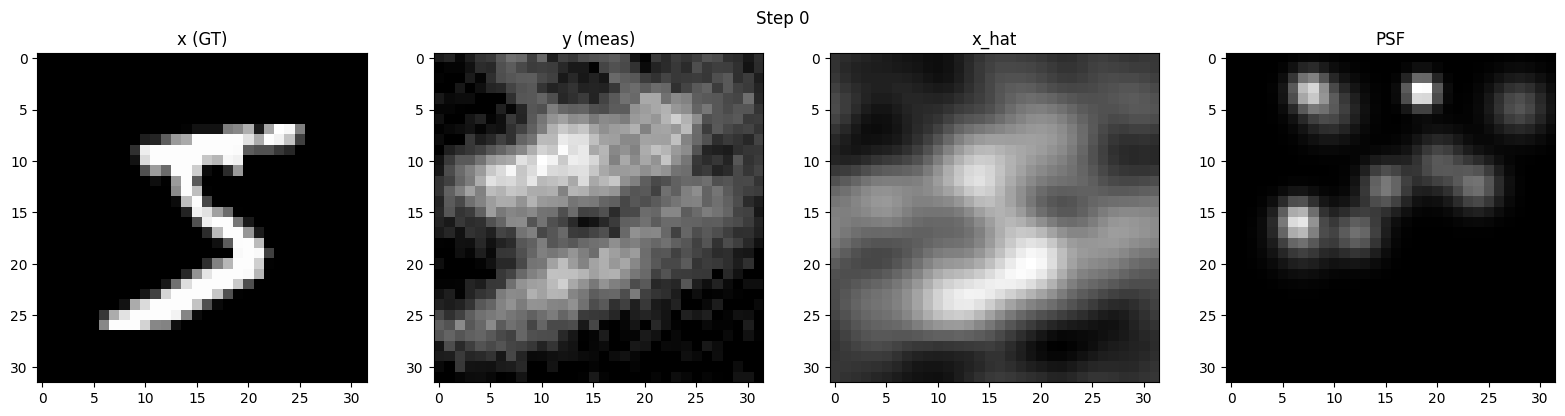

  3%|▎         | 14/500 [00:12<01:52,  4.34it/s] 

step 10/500  loss=0.060457  K=0.363849


  4%|▍         | 22/500 [00:13<00:49,  9.59it/s]

step 20/500  loss=0.058611  K=0.360227


  7%|▋         | 34/500 [00:14<00:33, 13.94it/s]

...

step 80/500  loss=0.048749  K=0.337907


 19%|█▉        | 94/500 [00:18<00:26, 15.44it/s]

step 90/500  loss=0.044294  K=0.334356


 20%|██        | 100/500 [00:18<00:26, 15.38it/s]

step 100/500  loss=0.038671  K=0.330990


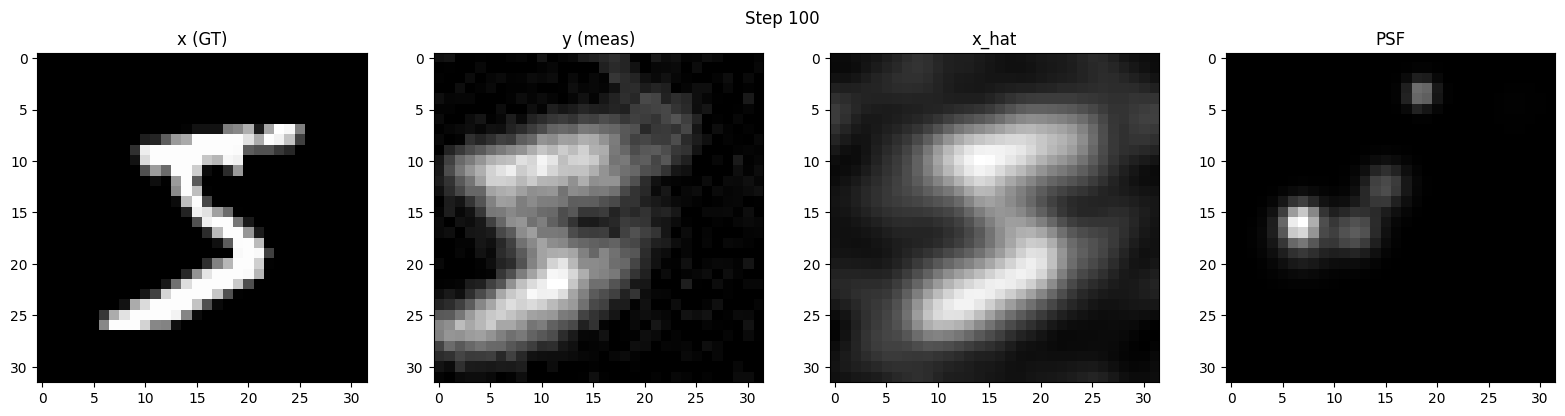

 23%|██▎       | 114/500 [00:19<00:27, 14.15it/s]

step 110/500  loss=0.039216  K=0.327773


 25%|██▍       | 124/500 [00:20<00:25, 15.02it/s]

step 120/500  loss=0.038535  K=0.324426


 27%|██▋       | 134/500 [00:21<00:24, 14.94it/s]

...

step 180/500  loss=0.025258  K=0.303669


 39%|███▉      | 194/500 [00:25<00:20, 15.28it/s]

step 190/500  loss=0.026743  K=0.300398


 40%|████      | 200/500 [00:25<00:19, 15.23it/s]

step 200/500  loss=0.025462  K=0.297058


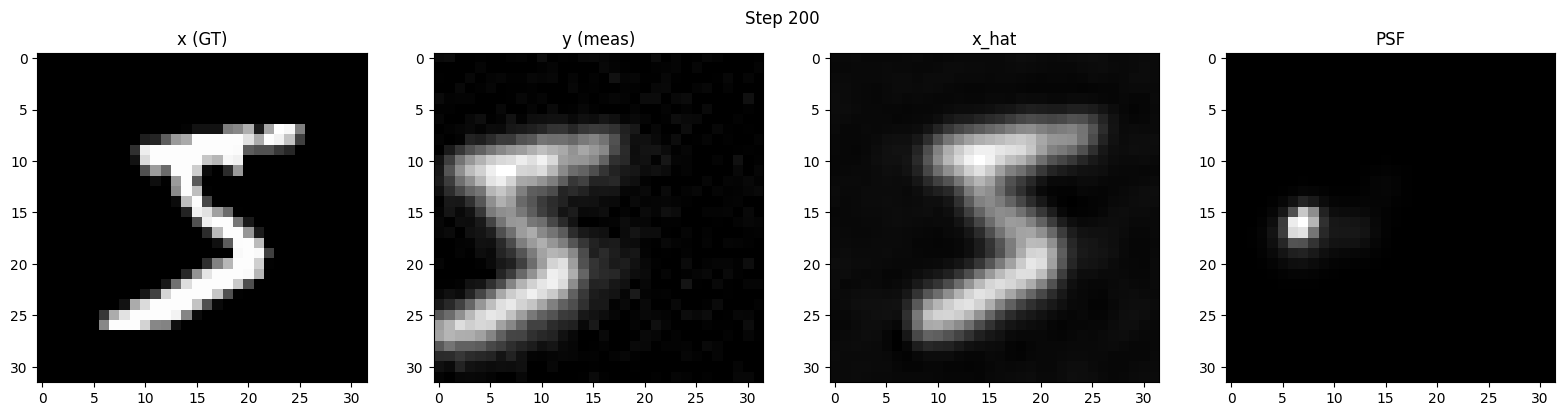

 43%|████▎     | 214/500 [00:27<00:23, 12.20it/s]

step 210/500  loss=0.021986  K=0.293974


 44%|████▍     | 222/500 [00:27<00:19, 14.13it/s]

step 220/500  loss=0.022185  K=0.291201


 46%|████▋     | 232/500 [00:28<00:18, 14.57it/s]

...

step 280/500  loss=0.017204  K=0.275764


 59%|█████▉    | 294/500 [00:32<00:13, 15.00it/s]

step 290/500  loss=0.018047  K=0.273352


 60%|██████    | 300/500 [00:32<00:13, 14.89it/s]

step 300/500  loss=0.015893  K=0.271002


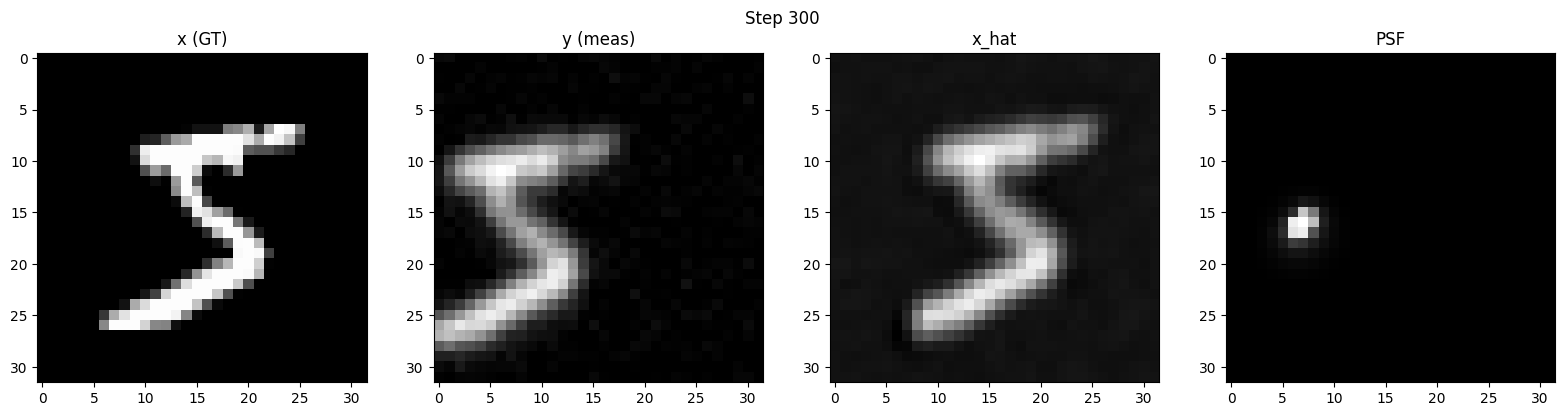

 63%|██████▎   | 314/500 [00:34<00:13, 13.69it/s]

step 310/500  loss=0.016826  K=0.268668


 64%|██████▍   | 322/500 [00:34<00:12, 14.21it/s]

step 320/500  loss=0.016197  K=0.266397


 67%|██████▋   | 334/500 [00:35<00:11, 14.14it/s]

...

step 380/500  loss=0.014392  K=0.253303


 79%|███████▉  | 394/500 [00:39<00:07, 15.10it/s]

step 390/500  loss=0.015144  K=0.251245


 80%|████████  | 400/500 [00:40<00:06, 14.90it/s]

step 400/500  loss=0.013114  K=0.249170


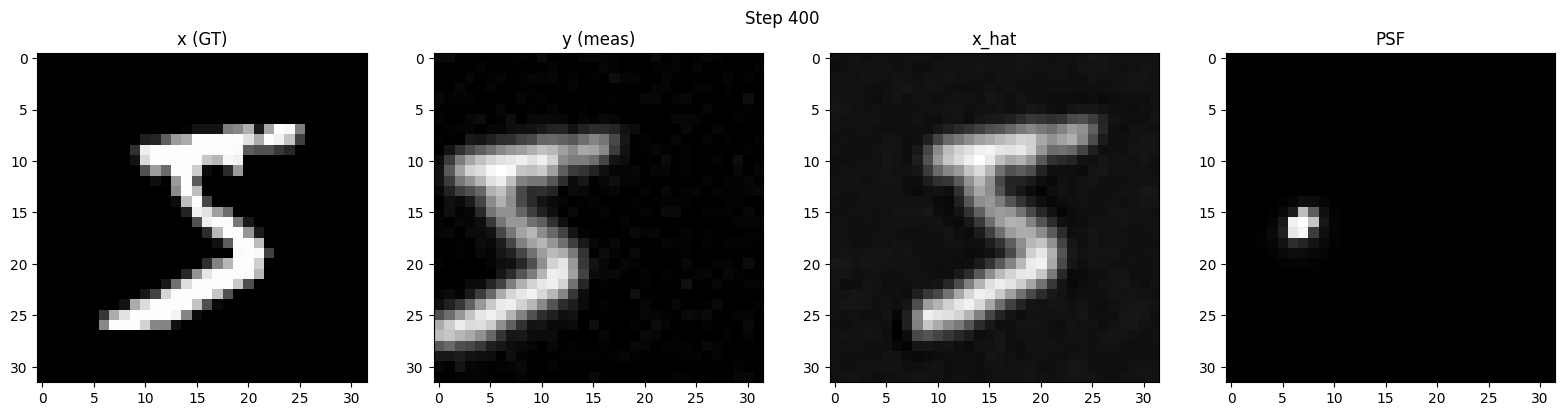

 82%|████████▏ | 412/500 [00:41<00:06, 13.25it/s]

step 410/500  loss=0.013853  K=0.247165


 85%|████████▍ | 424/500 [00:42<00:05, 14.90it/s]

step 420/500  loss=0.013440  K=0.245162


 86%|████████▋ | 432/500 [00:42<00:04, 14.78it/s]

...

step 480/500  loss=0.011856  K=0.234138


 98%|█████████▊| 492/500 [00:46<00:00, 14.74it/s]

step 490/500  loss=0.013073  K=0.232463


100%|█████████▉| 498/500 [00:47<00:00, 14.54it/s]

step 499/500  loss=0.010441  K=0.230958


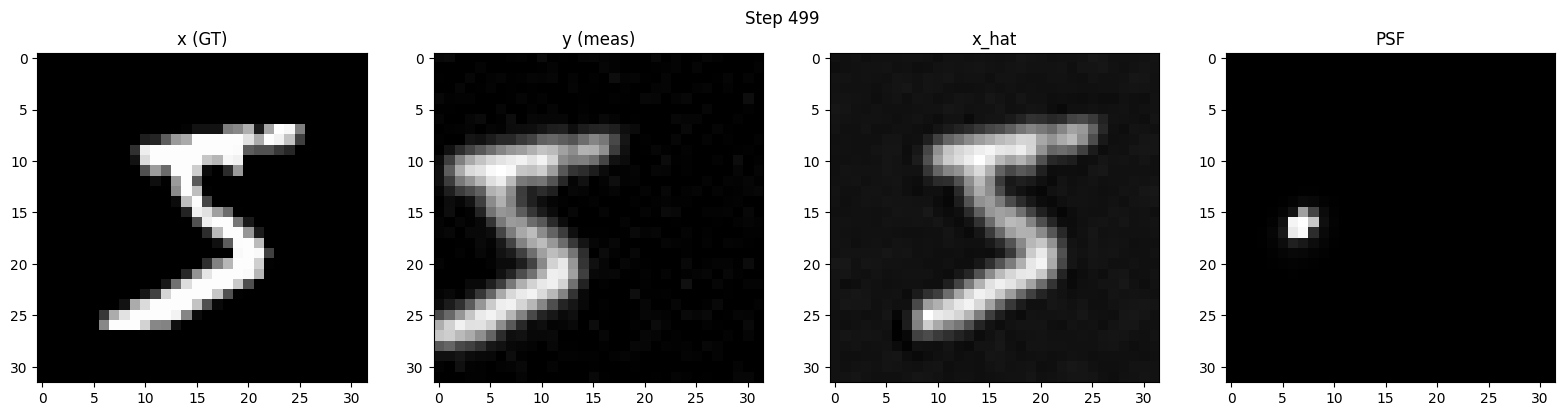

100%|██████████| 500/500 [00:47<00:00, 10.51it/s]


In [12]:
optimized_imaging_system = e2e_optimizer.optimize(
    train_dataset,
    num_steps=500,
    log_every=10,
    visualize_every=100,
    key=subkey_2
)

In [13]:
model.log_K

Array(-1., dtype=float32, weak_type=True)